In [17]:
import os
import sys
import math
import warnings
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator

In [18]:
# -----------------------------
# One cluster simulation
# Sigma_cloud = 1.0, e_ff = 0.03
# -----------------------------
BASE_HIGH_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0'
SIM_PATH = os.path.join(BASE_HIGH_DENSITY, 'sfeff003_00') + '/'

# -----------------------------
# Model setup
# -----------------------------
AKs = 0.0
dist = 410
metallicity = 0.0

evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawHosek18b()

# Fresh cache directory for this notebook
iso_dir = '/scratch/wyz5rge/synthetic-hr/cmd_mass_stratified_isochrones'
os.makedirs(iso_dir, exist_ok=True)

# Build all needed filters at once
ALL_FILTERS = [
    'jwst,F115W',
    'jwst,F162M',
    'jwst,F182M',
    'jwst,F200W',
]

FILTER_KEY_MAP = {
    'jwst,F115W': 'm_jwst_F115W',
    'jwst,F162M': 'm_jwst_F162M',
    'jwst,F182M': 'm_jwst_F182M',
    'jwst,F200W': 'm_jwst_F200W',
}

# CMDs to compare
CMD_CHOICES = [
    ('jwst,F115W', 'jwst,F200W', 'jwst,F200W', 'F115W-F200W vs F200W'),
    ('jwst,F162M', 'jwst,F182M', 'jwst,F162M', 'F162M-F182M vs F162M'),
    ('jwst,F162M', 'jwst,F182M', 'jwst,F182M', 'F162M-F182M vs F182M'),
    ('jwst,F162M', 'jwst,F200W', 'jwst,F200W', 'F162M-F200W vs F200W'),
    ('jwst,F115W', 'jwst,F162M', 'jwst,F162M', 'F115W-F162M vs F162M'),
]

# Mass bins for Baraffe range 0.01–1.4 Msun
# Slightly denser at low mass where most stars live
MASS_BIN_EDGES = np.array([0.01, 0.03, 0.08, 0.15, 0.30, 0.60, 1.00, 1.40])

# Time sampling for e_ff = 0.03
SNAPSHOT_TIMES_MYR = np.arange(0.5, 6.6, 0.25)

In [19]:
def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    return converter.to_spicea_table(snapshot)


def extract_masses_and_ages(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr


def compute_dt90(cluster_table):
    _, ages_myr, _ = extract_masses_and_ages(cluster_table)
    if len(ages_myr) < 2:
        return np.nan
    return np.percentile(ages_myr, 95) - np.percentile(ages_myr, 5)

In [20]:
def build_isochrone_grid(ages_yr, increment_yr=0.1e6, min_age_floor_yr=0.5e6):
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    iso_grid = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        iso_grid[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=ALL_FILTERS,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, iso_grid


def safe_interpolate(age_myr, mass, iso_grid, log_age_arr, filters):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                return interpolator.interpolate(age_myr, mass, iso_grid, log_age_arr, filters)
    except Exception:
        return None

In [21]:
def interpolate_snapshot_cmd(cluster_table, filt_a, filt_b, y_filter_name, increment_yr=0.1e6):
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

    level_age_arr_yr, log_age_arr, iso_grid = build_isochrone_grid(
        ages_yr,
        increment_yr=increment_yr
    )

    filt_key_a = FILTER_KEY_MAP[filt_a]
    filt_key_b = FILTER_KEY_MAP[filt_b]

    if y_filter_name == filt_a:
        y_filter_key = filt_key_a
    elif y_filter_name == filt_b:
        y_filter_key = filt_key_b
    else:
        raise ValueError("y_filter_name must equal filt_a or filt_b")

    rows = []
    for m, a in zip(masses, ages_myr):
        star = safe_interpolate(a, m, iso_grid, log_age_arr, [filt_key_a, filt_key_b])
        if star is None:
            continue

        lum = float(star[0])
        teff = float(star[1])
        logg = float(star[2])
        mag_a = float(star[3])
        mag_b = float(star[4])

        color = mag_a - mag_b
        ymag = mag_a if y_filter_key == filt_key_a else mag_b

        rows.append({
            'mass': m,
            'age_myr': a,
            'lum_watts': lum,
            'lum_lsun': lum / 3.846e26 if lum > 0 else np.nan,
            'teff': teff,
            'logg': logg,
            'mag_a': mag_a,
            'mag_b': mag_b,
            'color': color,
            'ymag': ymag,
        })

    df_cmd = pd.DataFrame(rows)
    return df_cmd

In [22]:
def quartile_gap(values):
    """
    Mean(top quartile) - mean(bottom quartile)
    For magnitude, this is faintest quartile mean - brightest quartile mean,
    because larger magnitudes are fainter.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 4:
        return np.nan

    values = np.sort(values)
    q = max(1, len(values) // 4)

    bottom = values[:q]   # brightest quartile
    top = values[-q:]     # faintest quartile

    return np.mean(top) - np.mean(bottom)

In [23]:
def compute_mass_stratified_spreads(df_cmd, cluster_table, mass_bin_edges=MASS_BIN_EDGES):
    """
    Compute CMD spread separately in each mass bin.
    Returns one row per mass bin.
    """
    rows = []
    dt90 = compute_dt90(cluster_table)

    for m_lo, m_hi in zip(mass_bin_edges[:-1], mass_bin_edges[1:]):
        sub = df_cmd[(df_cmd['mass'] >= m_lo) & (df_cmd['mass'] < m_hi)]
        n_stars = len(sub)

        if n_stars < 4:
            spread = np.nan
            mean_y = np.nan
        else:
            spread = quartile_gap(sub['ymag'].values)
            mean_y = np.mean(sub['ymag'].values)

        rows.append({
            'mass_lo': m_lo,
            'mass_hi': m_hi,
            'mass_bin_label': f'{m_lo:.2f}-{m_hi:.2f}',
            'n_stars_bin': n_stars,
            'spread_bin': spread,
            'mean_y_bin': mean_y,
            'dt90': dt90,
        })

    return pd.DataFrame(rows)

In [24]:
def build_massbin_time_series(sim_path, snapshot_times_myr, cmd_choice):
    filt_a, filt_b, y_filter_name, title = cmd_choice
    rows = []

    for t in snapshot_times_myr:
        try:
            cluster_table = load_cluster_table(sim_path, t)
            df_cmd = interpolate_snapshot_cmd(cluster_table, filt_a, filt_b, y_filter_name)

            df_bins = compute_mass_stratified_spreads(df_cmd, cluster_table)

            df_bins['t_myr'] = t
            df_bins['cmd_title'] = title
            df_bins['n_stars_cmd'] = len(df_cmd)

            rows.append(df_bins)

            print(f"{title}, t={t:.2f} done")
        except Exception as e:
            print(f"{title}, t={t:.2f} failed: {e}")

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)

In [25]:
def plot_cmd_with_mass_bins(sim_path, snapshot_time_myr, cmd_choice, mass_bin_edges=MASS_BIN_EDGES):
    filt_a, filt_b, y_filter_name, title = cmd_choice

    cluster_table = load_cluster_table(sim_path, snapshot_time_myr)
    df_cmd = interpolate_snapshot_cmd(cluster_table, filt_a, filt_b, y_filter_name)

    plt.figure(figsize=(7, 6))

    cmap = plt.get_cmap('viridis')
    n_bins = len(mass_bin_edges) - 1

    for i, (m_lo, m_hi) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        sub = df_cmd[(df_cmd['mass'] >= m_lo) & (df_cmd['mass'] < m_hi)]
        color = cmap(i / max(n_bins - 1, 1))

        plt.scatter(
            sub['color'], sub['ymag'],
            s=6, alpha=0.55, color=color,
            label=f'{m_lo:.2f}-{m_hi:.2f} Msun'
        )

    plt.xlabel(f'{filt_a} - {filt_b}')
    plt.ylabel(y_filter_name)
    plt.title(f'{title}\n t={snapshot_time_myr:.2f} Myr')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

Isochrone generation took 0.827698 s.
Making photometry for isochrone: log(t) = 5.70  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:47:22.896828   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F115W = 17.14
Starting filter: jwst,F162M   Elapsed time: 0.64 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F162M = 16.25
Starting filter: jwst,F182M   Elapsed time: 1.27 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F182M = 16.41
Starting filter: jwst,F200W   Elapsed time: 1.91 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F200W = 16.28
      Time taken: 2.54 seconds
Isochrone generation took 0.871510 s.
Making photometry for isochrone: log(t) = 5.78  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:47:26.325901   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 

Starting filter: jwst,F200W   Elapsed time: 2.16 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2292 K  m_jwst_F200W = 17.21
      Time taken: 2.87 seconds
Isochrone generation took 0.911134 s.
Making photometry for isochrone: log(t) = 6.20  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:48:04.852644   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F115W = 18.18
Starting filter: jwst,F162M   Elapsed time: 0.72 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F162M = 17.21
Starting filter: jwst,F182M   Elapsed time: 1.45 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F182M = 17.42
Starting filter: jwst,F200W   Elapsed time: 2.17 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2280 K  m_jwst_F200W = 17.27
      Time taken: 2.89 seconds


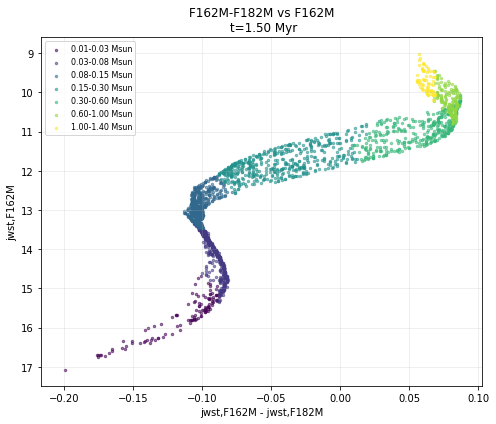

In [26]:
cmd_choice_main = ('jwst,F162M', 'jwst,F182M', 'jwst,F162M', 'F162M-F182M vs F162M')

plot_cmd_with_mass_bins(
    SIM_PATH,
    snapshot_time_myr=1.5,
    cmd_choice=cmd_choice_main
)

In [27]:
df_massbin_main = build_massbin_time_series(
    SIM_PATH,
    SNAPSHOT_TIMES_MYR,
    cmd_choice_main
)

df_massbin_main.head(20)

F162M-F182M vs F162M, t=0.50 failed: 'mass'
F162M-F182M vs F162M, t=0.75 done
F162M-F182M vs F162M, t=1.00 done
F162M-F182M vs F162M, t=1.25 done
F162M-F182M vs F162M, t=1.50 done
Isochrone generation took 0.959970 s.
Making photometry for isochrone: log(t) = 6.23  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:48:21.477412   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F115W = 18.24
Starting filter: jwst,F162M   Elapsed time: 0.72 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F162M = 17.26
Starting filter: jwst,F182M   Elapsed time: 1.46 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F182M = 17.48
Starting filter: jwst,F200W   Elapsed time: 2.19 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F200W = 17.33
      Time taken: 2.92 seconds
Isochrone generation took 0.954712 s.
Making photom

Starting filter: jwst,F162M   Elapsed time: 0.73 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2167 K  m_jwst_F162M = 17.70
Starting filter: jwst,F182M   Elapsed time: 1.44 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2167 K  m_jwst_F182M = 17.96
Starting filter: jwst,F200W   Elapsed time: 2.18 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2167 K  m_jwst_F200W = 17.79
      Time taken: 2.92 seconds
F162M-F182M vs F162M, t=2.50 done
Isochrone generation took 0.963182 s.
Making photometry for isochrone: log(t) = 6.45  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:49:23.658889   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2161 K  m_jwst_F115W = 18.78
Starting filter: jwst,F162M   Elapsed time: 0.75 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2161 K  m_jwst_F162M = 17.72
Starting filter: jwst,F182M   Elapsed time: 1.50 seconds
S

      Time taken: 2.89 seconds
Isochrone generation took 0.956417 s.
Making photometry for isochrone: log(t) = 6.58  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:50:17.941458   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F115W = 19.20
Starting filter: jwst,F162M   Elapsed time: 0.72 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F162M = 18.04
Starting filter: jwst,F182M   Elapsed time: 1.44 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F182M = 18.34
Starting filter: jwst,F200W   Elapsed time: 2.15 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2076 K  m_jwst_F200W = 18.14
      Time taken: 2.87 seconds
Isochrone generation took 0.952024 s.
Making photometry for isochrone: log(t) = 6.59  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:50:21.781384   Usually takes ~5 minutes
Starting filter: j

Starting filter: jwst,F162M   Elapsed time: 0.72 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F162M = 18.30
Starting filter: jwst,F182M   Elapsed time: 1.46 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F182M = 18.67
Starting filter: jwst,F200W   Elapsed time: 2.18 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F200W = 18.42
      Time taken: 2.96 seconds
Changing to logg=5.00 for T=  1960 logg=3.95
Isochrone generation took 0.959496 s.
Making photometry for isochrone: log(t) = 6.69  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:51:16.660613   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1960 K  m_jwst_F115W = 19.81
Starting filter: jwst,F162M   Elapsed time: 0.72 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1960 K  m_jwst_F162M = 18.30
Starting filter: jwst,F182M   Elapsed time: 1.4

Starting filter: jwst,F162M   Elapsed time: 0.96 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1870 K  m_jwst_F162M = 18.57
Starting filter: jwst,F182M   Elapsed time: 1.91 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1870 K  m_jwst_F182M = 18.92
Starting filter: jwst,F200W   Elapsed time: 2.85 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1870 K  m_jwst_F200W = 18.65
      Time taken: 3.79 seconds
Changing to logg=5.00 for T=  1862 logg=3.98
Isochrone generation took 0.997836 s.
Making photometry for isochrone: log(t) = 6.79  AKs = 0.00  dist = 410
     Starting at:  2026-04-15 04:52:16.209289   Usually takes ~5 minutes
Starting filter: jwst,F115W   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1862 K  m_jwst_F115W = 20.23
Starting filter: jwst,F162M   Elapsed time: 0.95 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1862 K  m_jwst_F162M = 18.61
Starting filter: jwst,F182M   Elapsed time: 1.8

,mass_lo,mass_hi,mass_bin_label,n_stars_bin,spread_bin,mean_y_bin,dt90,t_myr,cmd_title,n_stars_cmd
0,0.01,0.03,0.01-0.03,28,1.113429,15.266286,0.714752,0.75,F162M-F182M vs F162M,613
1,0.03,0.08,0.03-0.08,153,1.016974,13.881190,0.714752,0.75,F162M-F182M vs F162M,613
2,0.08,0.15,0.08-0.15,143,0.815429,12.793706,0.714752,0.75,F162M-F182M vs F162M,613
3,0.15,0.30,0.15-0.30,122,0.935867,11.472738,0.714752,0.75,F162M-F182M vs F162M,613
4,0.30,0.60,0.30-0.60,97,0.653250,10.589082,0.714752,0.75,F162M-F182M vs F162M,613
5,0.60,1.00,0.60-1.00,52,0.557385,9.902077,0.714752,0.75,F162M-F182M vs F162M,613
6,1.00,1.40,1.00-1.40,18,0.477500,9.348667,0.714752,0.75,F162M-F182M vs F162M,613
7,0.01,0.03,0.01-0.03,69,1.237706,15.453333,0.904656,1.00,F162M-F182M vs F162M,1264
8,0.03,0.08,0.03-0.08,314,1.095449,14.012484,0.904656,1.00,F162M-F182M vs F162M,1264
9,0.08,0.15,0.08-0.15,289,0.850889,12.835156,0.904656,1.00,F162M-F182M vs F162M,1264


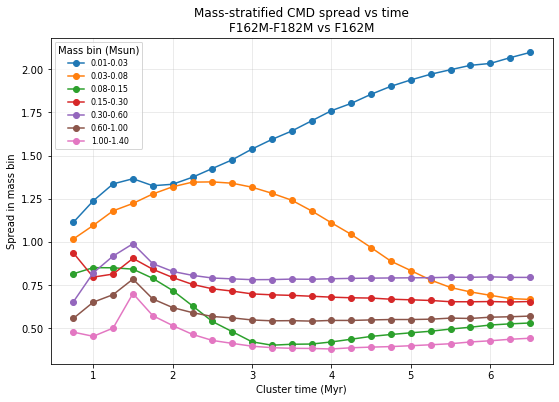

In [28]:
plt.figure(figsize=(9, 6))

for label in df_massbin_main['mass_bin_label'].unique():
    sub = df_massbin_main[
        (df_massbin_main['mass_bin_label'] == label) &
        np.isfinite(df_massbin_main['spread_bin'])
    ].sort_values('t_myr')

    plt.plot(sub['t_myr'], sub['spread_bin'], marker='o', label=label)

plt.xlabel('Cluster time (Myr)')
plt.ylabel('Spread in mass bin')
plt.title('Mass-stratified CMD spread vs time\nF162M-F182M vs F162M')
plt.grid(alpha=0.3)
plt.legend(title='Mass bin (Msun)', fontsize=8)
plt.show()

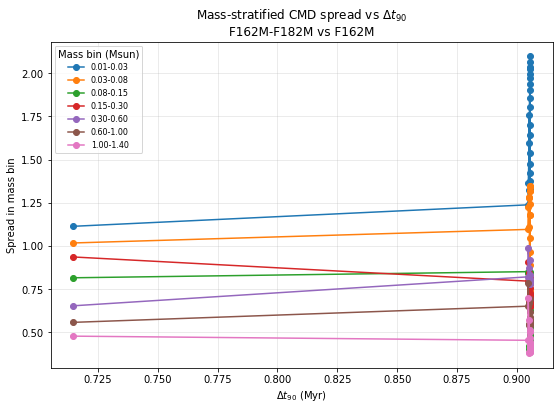

In [29]:
plt.figure(figsize=(9, 6))

for label in df_massbin_main['mass_bin_label'].unique():
    sub = df_massbin_main[
        (df_massbin_main['mass_bin_label'] == label) &
        np.isfinite(df_massbin_main['spread_bin'])
    ].sort_values('dt90')

    plt.plot(sub['dt90'], sub['spread_bin'], marker='o', label=label)

plt.xlabel(r'$\Delta t_{90}$ (Myr)')
plt.ylabel('Spread in mass bin')
plt.title(r'Mass-stratified CMD spread vs $\Delta t_{90}$' '\n' 'F162M-F182M vs F162M')
plt.grid(alpha=0.3)
plt.legend(title='Mass bin (Msun)', fontsize=8)
plt.show()

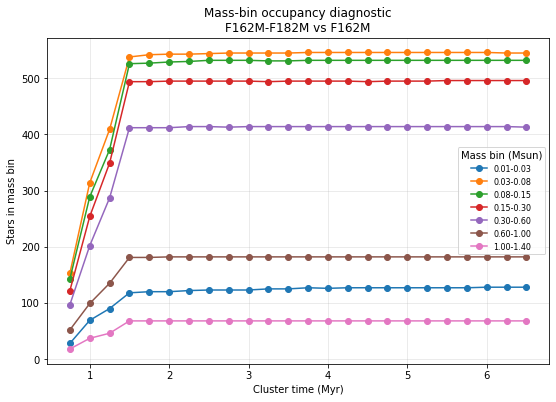

In [30]:
plt.figure(figsize=(9, 6))

for label in df_massbin_main['mass_bin_label'].unique():
    sub = df_massbin_main[df_massbin_main['mass_bin_label'] == label].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['n_stars_bin'], marker='o', label=label)

plt.xlabel('Cluster time (Myr)')
plt.ylabel('Stars in mass bin')
plt.title('Mass-bin occupancy diagnostic\nF162M-F182M vs F162M')
plt.grid(alpha=0.3)
plt.legend(title='Mass bin (Msun)', fontsize=8)
plt.show()

In [31]:
all_cmd_dfs = []

for cmd_choice in CMD_CHOICES:
    df_cmd = build_massbin_time_series(
        SIM_PATH,
        SNAPSHOT_TIMES_MYR,
        cmd_choice
    )
    all_cmd_dfs.append(df_cmd)

df_all_massbin = pd.concat(all_cmd_dfs, ignore_index=True)
df_all_massbin.head()

F115W-F200W vs F200W, t=0.50 failed: 'mass'
F115W-F200W vs F200W, t=0.75 done
F115W-F200W vs F200W, t=1.00 done
F115W-F200W vs F200W, t=1.25 done
F115W-F200W vs F200W, t=1.50 done
F115W-F200W vs F200W, t=1.75 done
F115W-F200W vs F200W, t=2.00 done
F115W-F200W vs F200W, t=2.25 done
F115W-F200W vs F200W, t=2.50 done
F115W-F200W vs F200W, t=2.75 done
F115W-F200W vs F200W, t=3.00 done
F115W-F200W vs F200W, t=3.25 done
F115W-F200W vs F200W, t=3.50 done
F115W-F200W vs F200W, t=3.75 done
F115W-F200W vs F200W, t=4.00 done
F115W-F200W vs F200W, t=4.25 done
F115W-F200W vs F200W, t=4.50 done
F115W-F200W vs F200W, t=4.75 done
F115W-F200W vs F200W, t=5.00 done
F115W-F200W vs F200W, t=5.25 done
F115W-F200W vs F200W, t=5.50 done
F115W-F200W vs F200W, t=5.75 done
F115W-F200W vs F200W, t=6.00 done
F115W-F200W vs F200W, t=6.25 done
F115W-F200W vs F200W, t=6.50 done
F162M-F182M vs F162M, t=0.50 failed: 'mass'
F162M-F182M vs F162M, t=0.75 done
F162M-F182M vs F162M, t=1.00 done
F162M-F182M vs F162M, t=1.25

,mass_lo,mass_hi,mass_bin_label,n_stars_bin,spread_bin,mean_y_bin,dt90,t_myr,cmd_title,n_stars_cmd
0,0.01,0.03,0.01-0.03,28,1.118714,15.273286,0.714752,0.75,F115W-F200W vs F200W,613
1,0.03,0.08,0.03-0.08,153,0.990658,13.902013,0.714752,0.75,F115W-F200W vs F200W,613
2,0.08,0.15,0.08-0.15,143,0.808743,12.840448,0.714752,0.75,F115W-F200W vs F200W,613
3,0.15,0.30,0.15-0.30,122,1.003100,11.480148,0.714752,0.75,F115W-F200W vs F200W,613
4,0.30,0.60,0.30-0.60,97,0.694875,10.507979,0.714752,0.75,F115W-F200W vs F200W,613


In [32]:
chosen_bin = '0.08-0.15'

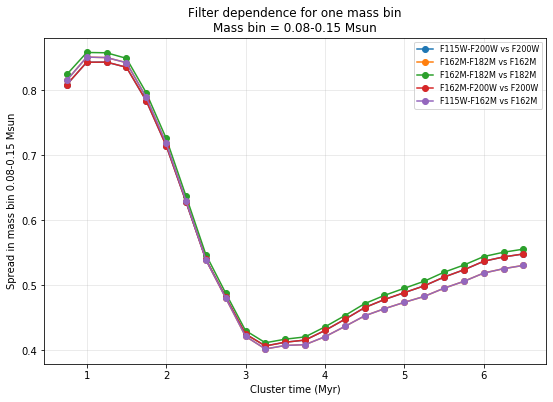

In [33]:
plt.figure(figsize=(9, 6))

for title in df_all_massbin['cmd_title'].unique():
    sub = df_all_massbin[
        (df_all_massbin['cmd_title'] == title) &
        (df_all_massbin['mass_bin_label'] == chosen_bin) &
        np.isfinite(df_all_massbin['spread_bin'])
    ].sort_values('t_myr')

    plt.plot(sub['t_myr'], sub['spread_bin'], marker='o', label=title)

plt.xlabel('Cluster time (Myr)')
plt.ylabel(f'Spread in mass bin {chosen_bin} Msun')
plt.title(f'Filter dependence for one mass bin\nMass bin = {chosen_bin} Msun')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.show()

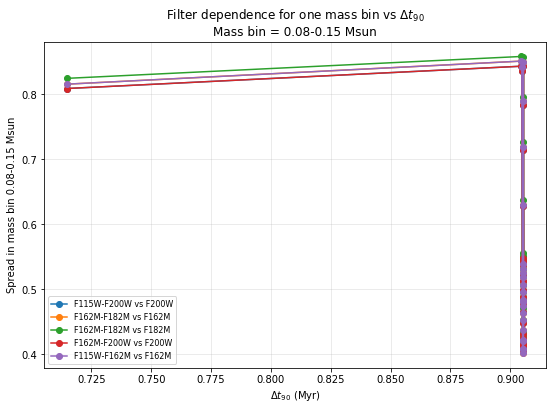

In [34]:
plt.figure(figsize=(9, 6))

for title in df_all_massbin['cmd_title'].unique():
    sub = df_all_massbin[
        (df_all_massbin['cmd_title'] == title) &
        (df_all_massbin['mass_bin_label'] == chosen_bin) &
        np.isfinite(df_all_massbin['spread_bin'])
    ].sort_values('dt90')

    plt.plot(sub['dt90'], sub['spread_bin'], marker='o', label=title)

plt.xlabel(r'$\Delta t_{90}$ (Myr)')
plt.ylabel(f'Spread in mass bin {chosen_bin} Msun')
plt.title(f'Filter dependence for one mass bin vs $\Delta t_{{90}}$\nMass bin = {chosen_bin} Msun')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.show()

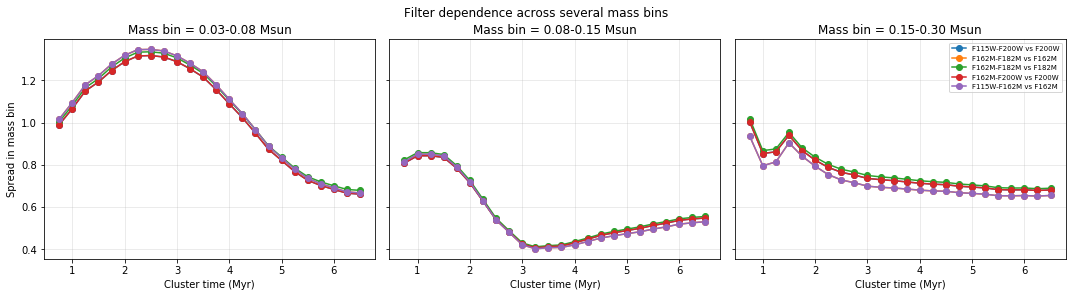

In [35]:
candidate_bins = ['0.03-0.08', '0.08-0.15', '0.15-0.30']

fig, axes = plt.subplots(1, len(candidate_bins), figsize=(5 * len(candidate_bins), 4), sharey=True)

if len(candidate_bins) == 1:
    axes = [axes]

for ax, chosen_bin in zip(axes, candidate_bins):
    for title in df_all_massbin['cmd_title'].unique():
        sub = df_all_massbin[
            (df_all_massbin['cmd_title'] == title) &
            (df_all_massbin['mass_bin_label'] == chosen_bin) &
            np.isfinite(df_all_massbin['spread_bin'])
        ].sort_values('t_myr')

        ax.plot(sub['t_myr'], sub['spread_bin'], marker='o', label=title)

    ax.set_title(f'Mass bin = {chosen_bin} Msun')
    ax.set_xlabel('Cluster time (Myr)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Spread in mass bin')
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize=7)

plt.suptitle('Filter dependence across several mass bins', y=1.02)
plt.tight_layout()
plt.show()